In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

In [ ]:
#Load dataset
df = pd.read_csv('/content/Credis_Score_Dataset_B.csv')

#Head of dataset
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0xc765,CUS_0xade3,April,Kevin Limx,49,#F%$D@*&8,Entrepreneur,165076.44,NaN,1,...,Good,712.94,29.051769,18 Years and 2 Months,No,273.174717,1130.5113527934434,Low_spent_Large_value_payments,248.55092985209012,Standard
1,0x1fbf9,CUS_0x7651,April,Slaterv,40,300-72-2019,Manager,57321.36,4666.780,10,...,Bad,2224.09,27.436038,NaN,Yes,420.888678,68.80243048143443,High_spent_Medium_value_payments,226.9868910810159,Standard
2,0x15891,CUS_0x84fe,April,Leee,38,579-44-7984,_______,30111.3,NaN,7,...,Bad,3075.29,38.259660,4 Years and 2 Months,Yes,140.836626,__10000__,High_spent_Small_value_payments,257.0932938020279,Poor
3,0x3ee7,CUS_0x7620,June,Fionag,24,#F%$D@*&8,Developer,36496.38_,2934.365,8,...,Standard,1328.69,36.750990,NaN,Yes,45.812349,NaN,High_spent_Medium_value_payments,390.7583756600934,Poor
4,0x1e5aa,CUS_0x5572,May,Hyunjoo Jina,39,972-53-4211,Scientist,10068.97,NaN,8,...,Standard,2192.93,28.617576,15 Years and 1 Months,NM,23.222251,46.55878243363996,Low_spent_Medium_value_payments,294.2270494281999,Standard


In [ ]:
df.shape

(50000, 28)

Data terdiri dari 50000 baris dan 28 kolom.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        50000 non-null  object 
 1   Customer_ID               50000 non-null  object 
 2   Month                     50000 non-null  object 
 3   Name                      45058 non-null  object 
 4   Age                       50000 non-null  object 
 5   SSN                       50000 non-null  object 
 6   Occupation                50000 non-null  object 
 7   Annual_Income             50000 non-null  object 
 8   Monthly_Inhand_Salary     42512 non-null  float64
 9   Num_Bank_Accounts         50000 non-null  int64  
 10  Num_Credit_Card           50000 non-null  int64  
 11  Interest_Rate             50000 non-null  int64  
 12  Num_of_Loan               50000 non-null  object 
 13  Type_of_Loan              44324 non-null  object 
 14  Delay_

 ## a. Conduct an Exploratory Data Analysis (EDA) on the dataset. Highlight the main insights and any irregularities you find, and address those anomalies appropriately!

### Data Preparation Before Splitting

In [ ]:
#Drop irrelevant columns
drop_cols = ['ID', 'Customer_ID', 'Name', 'SSN']
df = df.drop(columns=drop_cols)

1. ID dan Customer_ID -> karena hanya berfungsi sebagai penanda unik dan tidak memberikan informasi tentang perilaku keuangan atau kelayakan kredit seseorang.
2. Name -> karena hanya identitas pribadi, tidak punya nilai untuk analisis.
3. SSN -> karena berisi data sensitif dan tidak membantu dalam memahami maupun memprediksi credit score.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     50000 non-null  object 
 1   Age                       50000 non-null  object 
 2   Occupation                50000 non-null  object 
 3   Annual_Income             50000 non-null  object 
 4   Monthly_Inhand_Salary     42512 non-null  float64
 5   Num_Bank_Accounts         50000 non-null  int64  
 6   Num_Credit_Card           50000 non-null  int64  
 7   Interest_Rate             50000 non-null  int64  
 8   Num_of_Loan               50000 non-null  object 
 9   Type_of_Loan              44324 non-null  object 
 10  Delay_from_due_date       50000 non-null  int64  
 11  Num_of_Delayed_Payment    46398 non-null  object 
 12  Changed_Credit_Limit      50000 non-null  object 
 13  Num_Credit_Inquiries      48993 non-null  float64
 14  Credit

Beberapa kolom memiliki tipe data yang tidak sesuai.

In [ ]:
#Data type fixing
numeric_cols = [
    "Age",
    "Annual_Income",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Outstanding_Debt",
    "Amount_invested_monthly",
    "Monthly_Balance"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

#Convert categorical columns explicitly
categorical_cols = [
    "Month",
    "Occupation",
    "Type_of_Loan",
    "Credit_Mix",
    "Payment_of_Min_Amount",
    "Payment_Behaviour",
]

for col in categorical_cols:
    df[col] = df[col].astype("object")

## Check Data Problems

In [ ]:
#Check duplicate
df.duplicated().sum()

np.int64(0)

Tidak ada baris duplikat.

In [ ]:
#Check Inconsistent and Invalid Values
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].dropna().unique())


Column: Month
['April' 'June' 'May' 'August' 'February' 'January' 'July' 'March']

Column: Age
[  49.   40.   38.   24.   39.   34.   32.   36.   25.   52.   21. 4592.
   16.   37.   29.   19.   27.   22.   42.   28.   46.   31.   20.   44.
   18. -500.   51.   41.   48.   33.   30.   53.   47.  344.   54.   26.
 1083.   55.   35.   17.   23.   15. 1527.   45.   43.   14.   56. 3602.
 7197.   50. 4431.  528. 1040. 5456. 1644. 1363. 2919. 5202. 4607. 4958.
 5742. 3555. 1308. 1683. 5938. 5714. 1842. 2679. 5828. 5377. 2751. 5063.
 2321. 1908. 7925. 2074. 2558. 4017. 5793. 8031. 1583. 3546. 4501. 2471.
 6295. 1289. 7060. 5924. 8490. 7131. 7849. 5579.  123.  995. 1424. 1751.
 6713. 1642. 7388. 4906. 3262. 3992. 2578. 5940. 2081.  540. 6007. 4661.
 3119. 2634. 4494. 8286. 8338. 5970. 2822. 5400. 3378. 3726. 1364. 6925.
 6189. 7710. 6651. 6939. 5509. 7967. 8235. 2343. 3720. 7014. 2712. 7123.
 8154. 2352. 2037. 5936. 6909. 5140. 6254. 1136.  305. 5154. 3194. 3913.
 6190. 1689. 5608. 1925. 494

1. Age -> Banyak nilai yang tidak masuk akal, seperti angka negatif (-500) dan usia ribuan (misalnya 4592, 8031).
2. Occupation -> Mayoritas berisi nama pekerjaan yang valid, tapi terdapat nilai '_______' dan sebaiknya dianggap sebagai missing value.
3. Num_Bank_Accounts -> Ada nilai yang tidak realistis seperti -1 dan mencapai ribuan.
4. Num_of_Loan -> Terdapat nilai negatif (-100) dan angka sangat besar (ratusan hingga ribuan).
5. Payment_of_Min_Amount -> Adanya nilai 'NM' cukup ambigu karena kemungkinan salah input atau bermakna lain.
6. Payment_Behaviour -> Terdapat nilai '!@9#%8', menunjukkan noise atau kesalahan input.
7. Credit_Mix -> Terdapat nilai '_', sebaiknya dianggap sebagai missing value.
8. Delay_from_due_date -> nilai negatif dianggap tidak valid karena keterlambatan pembayaran tidak mungkin bernilai negatif.
9. Type_of_Loan -> Ada 'Not Specified', sebaiknya dianggap sebagai missing value.
10. Num_Credit_Card, Interest_Rate -> jumlahnya sampai ratusan atau ribuan, tidak valid.


In [ ]:
#Check Missing Values
df.isna().sum()

,0
Month,0
Age,2483
Occupation,0
Annual_Income,3518
Monthly_Inhand_Salary,7488
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0
Num_of_Loan,2417
Type_of_Loan,5676


Kolom dengan missing value:
1. Age -> 2.483
2. Annual_Income -> 3.518
3. Monthly_Inhand_Salary -> 7.488
4. Num_of_Loan -> 2.417
5. Type_of_Loan -> 5.676
6. Num_of_Delayed_Payment -> 4.968
7. Changed_Credit_Limit -> 1.028
8. Num_Credit_Inquiries -> 1.007
9. Outstanding_Debt -> 508
10. Credit_History_Age -> 4.464
11. Amount_invested_monthly -> 4.353
12. Monthly_Balance -> 615

In [ ]:
#Check for outliers
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) | (df[col] > upper_bound)
    ][col]

    outlier_summary.append({
        'column': col,
        'outlier_count': outliers.shape[0],
        'outlier_min': outliers.min() if not outliers.empty else None,
        'outlier_max': outliers.max() if not outliers.empty else None
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df[outlier_df['outlier_count'] > 0]

,column,outlier_count,outlier_min,outlier_max
0,Age,1336,-500.000000,8.682000e+03
1,Annual_Income,1278,154242.480000,2.419806e+07
2,Monthly_Inhand_Salary,834,12495.470000,1.520463e+04
3,Num_Bank_Accounts,638,27.000000,1.798000e+03
4,Num_Credit_Card,1179,15.000000,1.499000e+03
5,Interest_Rate,1047,59.000000,5.797000e+03
6,Num_of_Loan,2101,-100.000000,1.496000e+03
7,Delay_from_due_date,2007,56.000000,6.700000e+01
8,Num_of_Delayed_Payment,359,49.000000,4.384000e+03
9,Changed_Credit_Limit,370,29.110000,3.697000e+01


1. Age: Perlu di-handle karena ada nilai negatif dan usia ribuan tahun, yang jelas tidak mungkin.
2. Annual_Income: Perlu di-handle karena memiliki nilai sangat ekstrem (hingga puluhan juta) yang bisa mendistorsi analisis.
3. Monthly_Inhand_Salary: Masih perlu dicek karena nilai maksimumnya cukup tinggi dan berpotensi tidak konsisten dengan income tahunan.
4. Num_Bank_Accounts: Perlu di-handle karena ada nilai puluhan hingga ribuan rekening bank, yang tidak realistis.
5. Num_Credit_Card: Perlu di-handle karena jumlah kartu kredit mencapai ratusan hingga ribuan.
6. Interest_Rate: Wajib di-handle karena suku bunga ribuan persen jelas tidak masuk akal.
7. Num_of_Loan: Perlu di-handle karena ada nilai negatif dan jumlah pinjaman yang sangat besar.
8. Delay_from_due_date: Perlu ditinjau karena keterlambatan hingga puluhan hari masih mungkin, tapi jumlah outliernya besar dan bisa mengganggu model.
9. Num_of_Delayed_Payment: Perlu di-handle karena jumlah keterlambatan bisa mencapai ribuan kali.
10. Changed_Credit_Limit: Perlu di-handle karena perubahan limit sangat besar dan tidak umum.
11. Num_Credit_Inquiries: Perlu di-handle karena jumlah inquiry kredit hingga ribuan tidak realistis.
12. Outstanding_Debt: Perlu di-handle karena nilai utang yang sangat tinggi berpotensi mendominasi analisis.
13. Total_EMI_per_month: Perlu di-handle karena cicilan bulanan bisa mencapai puluhan ribu, jauh dari nilai mayoritas data.
14. Amount_invested_monthly: Perlu di-handle karena nilai investasi bulanan yang terlalu besar dibandingkan mayoritas data.
15. Monthly_Balance: Perlu di-handle karena saldo bulanan sangat tinggi dan jumlah outliernya besar.
16. Credit_Utilization_Ratio: Tidak terlalu perlu ditangani, karena hanya memiliki 2 outlier dan nilainya masih dalam batas logis (≤100%).

In [ ]:
# Encode Target Column
credit_score_map = {
    "Poor": 1,
    "Standard": 2,
    "Good": 3
}

df["Credit_Score"] = df["Credit_Score"].map(credit_score_map)

## Split Data

In [ ]:
#Select Features (X) and Target (y)
input = df.drop('Credit_Score', axis = 1)
output = df['Credit_Score']

#Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(input, output, test_size=0.3, random_state=0, stratify=output)

print("x_train: ", x_train.shape)
print("x_test: ", x_test.shape)

x_train:  (35000, 23)
x_test:  (15000, 23)


* Train data -> 70%
* Test data -> 30%


## Handle Data Problems

### Handle Inconsistent and Invalid

In [ ]:
#Change to missing value
invalid = {
    '_______': np.nan,
    '_': np.nan,
    '!@9#%8': np.nan,
    'NM': np.nan,
    'Not Specified': np.nan
}

x_train.replace(invalid, inplace=True)
x_test.replace(invalid, inplace=True)

Nilai seperti '_______', '_', '!@9#%8', 'NM', dan 'Not Specified' diubah menjadi NaN karena merupakan placeholder yang tidak memiliki makna informatif. Jika dibiarkan, nilai tersebut dapat menimbulkan noise atau dianggap sebagai kategori valid saat encoding. Mengubahnya ke missing value memungkinkan penanganan data yang lebih konsisten melalui proses imputasi.

In [ ]:
for df_ in [x_train, x_test]:
    df_.loc[(df_['Age'] < 18) | (df_['Age'] > 90), 'Age'] = np.nan
    df_.loc[(df_['Delay_from_due_date'] < 0) | (df_['Delay_from_due_date'] > 120), 'Delay_from_due_date'] = np.nan
    df_.loc[(df_['Num_Bank_Accounts'] < 0) | (df_['Num_Bank_Accounts'] > 20), 'Num_Bank_Accounts'] = np.nan
    df_.loc[(df_['Num_Credit_Card'] < 0) | (df_['Num_Credit_Card'] > 15), 'Num_Credit_Card'] = np.nan
    df_.loc[(df_['Num_of_Loan'] < 0) | (df_['Num_of_Loan'] > 15), 'Num_of_Loan'] = np.nan
    df_.loc[(df_['Interest_Rate'] <= 0) | (df_['Interest_Rate'] > 50), 'Interest_Rate'] = np.nan

Nilai pada beberapa fitur numerik dibatasi berdasarkan rentang yang masuk akal secara logis (misalnya usia 18-90 tahun atau suku bunga 0-50) untuk mendeteksi data yang tidak realistis. Nilai yang berada di luar batas tersebut dianggap sebagai kesalahan pencatatan atau outlier ekstrem, sehingga diubah menjadi NaN.

In [ ]:
# Change Credit_History_Age to Months
def credit_age_to_months(x):
    if pd.isna(x):
        return np.nan
    try:
        x = x.strip()
        years = 0
        months = 0

        if 'Year' in x:
            years = int(x.split(' Year')[0])

        if 'Month' in x:
            if 'and' in x:
                months = int(x.split('and ')[1].split(' Month')[0])
            else:
                months = int(x.split(' Month')[0])

        return years * 12 + months
    except:
        return np.nan

for df_ in [x_train, x_test]:
    df_['Credit_History_Age_Months'] = df_['Credit_History_Age'].apply(credit_age_to_months)
    df_.drop(columns='Credit_History_Age', inplace=True)

Kolom Credit_History_Age diubah ke satuan bulan agar memiliki format numerik yang konsisten dan dapat digunakan langsung dalam pemodelan. Fungsi ini mengekstrak informasi tahun dan bulan dari data berbentuk teks, lalu mengonversinya menjadi total bulan. Jika format data tidak valid atau tidak dapat diproses, nilainya diubah menjadi NaN agar dapat ditangani pada tahap imputasi selanjutnya.

### Handle Outliers

In [ ]:
#Handle Use Capping
outlier_cols = [
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Num_Credit_Inquiries",
    "Outstanding_Debt",
    "Total_EMI_per_month",
    "Amount_invested_monthly",
    "Monthly_Balance"
]

def iqr_capping(df_train, df_test, columns):
    for col in columns:
        Q1 = df_train[col].quantile(0.25)
        Q3 = df_train[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_train[col] = df_train[col].clip(lower, upper)
        df_test[col] = df_test[col].clip(lower, upper)

    return df_train, df_test

x_train, x_test = iqr_capping(x_train, x_test, outlier_cols)

Outlier pada beberapa fitur numerik ditangani menggunakan IQR capping untuk membatasi nilai ekstrem tanpa menghapus data. Batas bawah dan atas dihitung dari data training agar distribusi tetap representatif dan menghindari data leakage, lalu nilai yang berada di luar batas tersebut dipotong ke nilai maksimum atau minimum yang diizinkan.

### Handle Missing Value

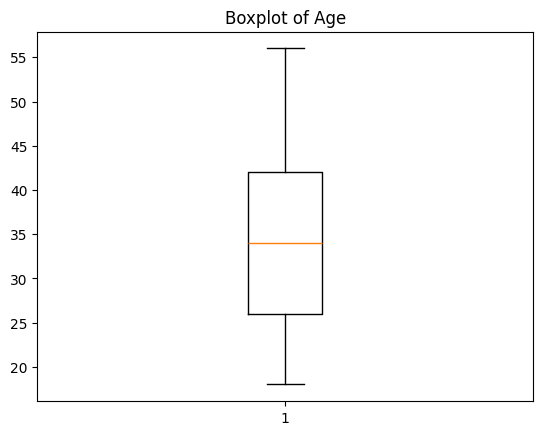

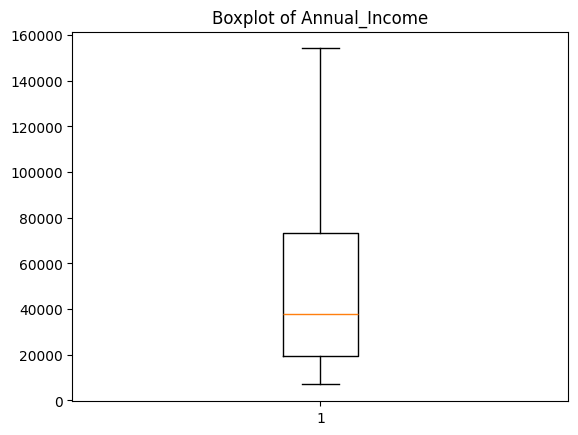

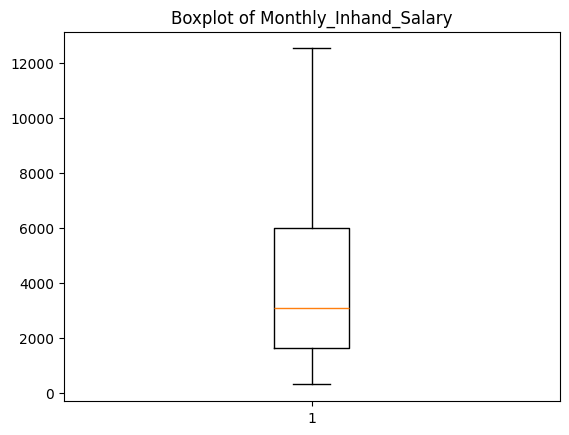

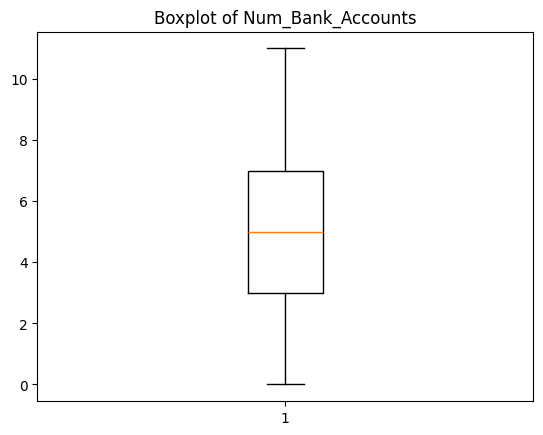

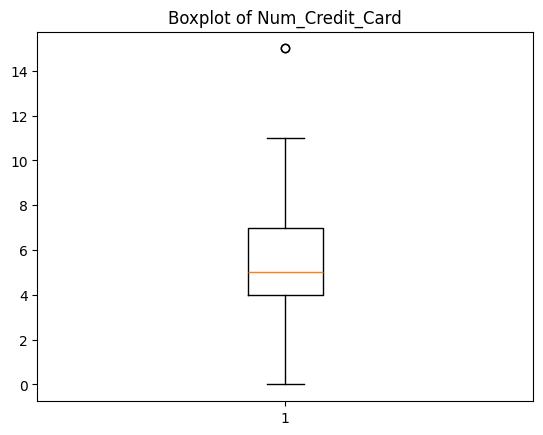

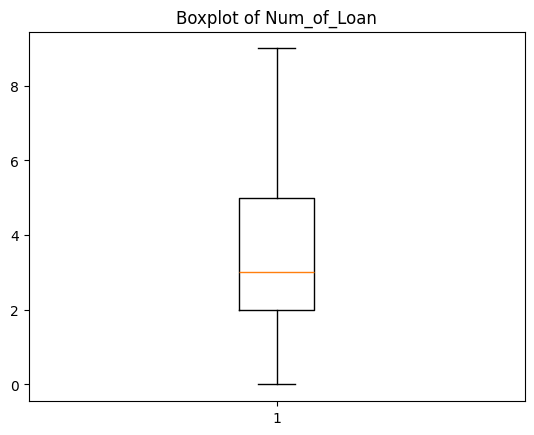

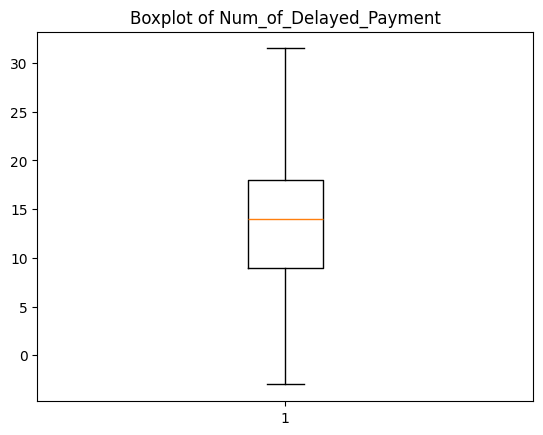

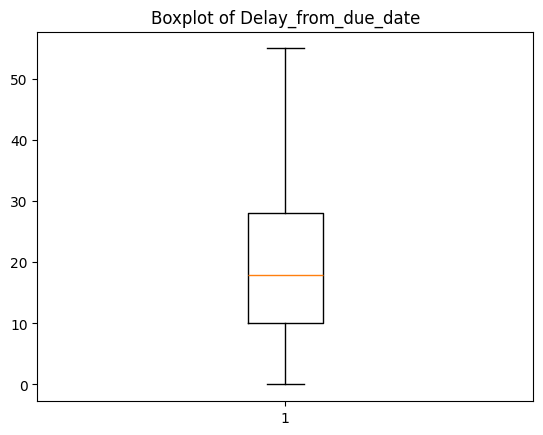

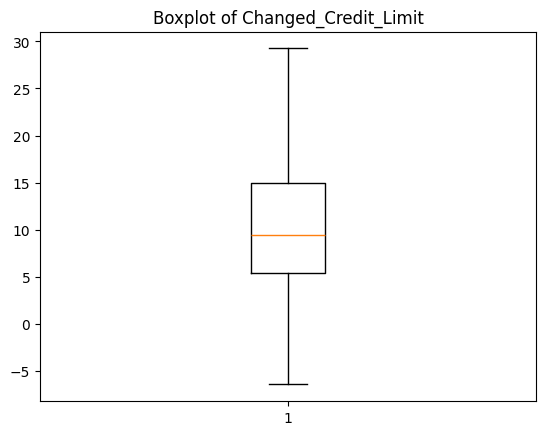

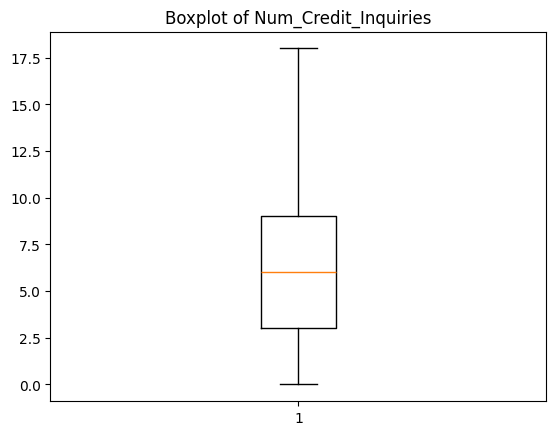

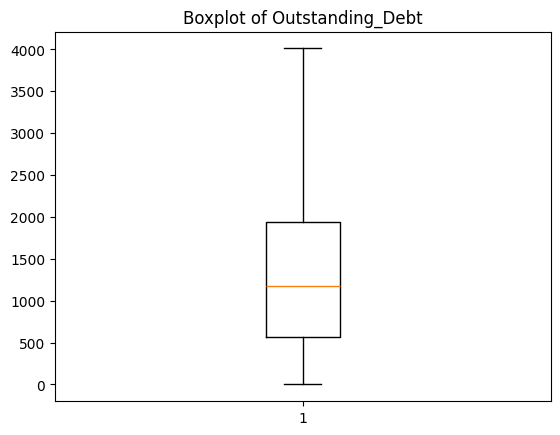

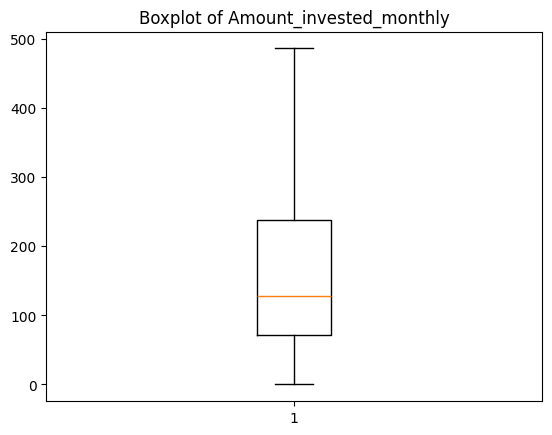

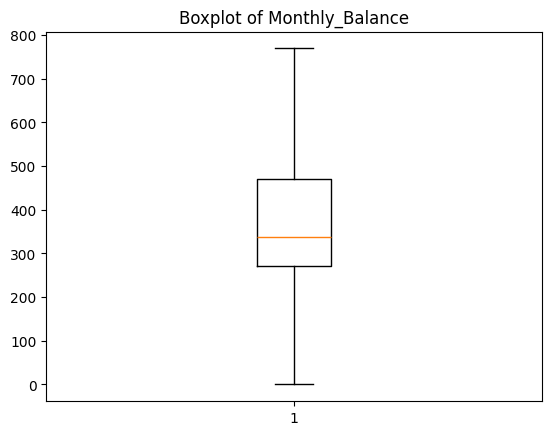

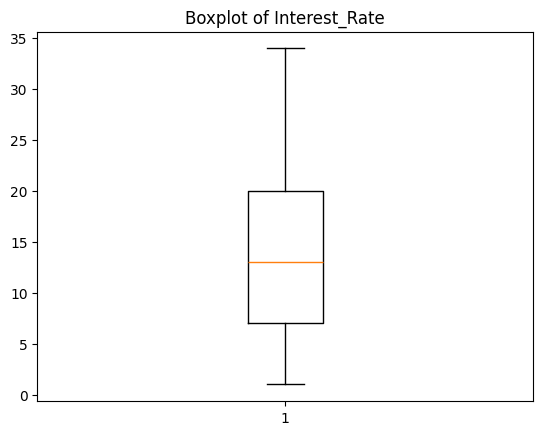

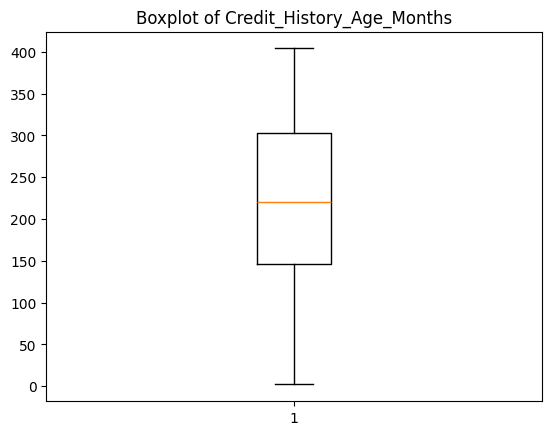

In [ ]:
#Boxplot
num_cols = ["Age", "Annual_Income", "Monthly_Inhand_Salary",
            "Num_Bank_Accounts", "Num_Credit_Card", "Num_of_Loan", "Num_of_Delayed_Payment",
            "Delay_from_due_date", "Changed_Credit_Limit", "Num_Credit_Inquiries",
            "Outstanding_Debt", "Amount_invested_monthly",
            "Monthly_Balance", "Interest_Rate", "Credit_History_Age_Months"]

for col in num_cols:
    plt.figure()
    plt.boxplot(x_train[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
# Impute for numeric columns
for col in num_cols:
    mean = x_train[col].mean()
    x_train[col].fillna(mean, inplace=True)
    x_test[col].fillna(mean, inplace=True)

Kolom missing value numerik diimputasi menggunakan mean karena sebagian besar data terdistribusi normal.

In [ ]:
# Impute for categorical columns
cat_cols = ["Credit_Mix", "Payment_Behaviour", "Payment_of_Min_Amount", "Occupation"]

for col in cat_cols:
    mode = x_train[col].mode()[0]
    x_train[col].fillna(mode, inplace=True)
    x_test[col].fillna(mode, inplace=True)

Handle kolom-kolom kategorikal menggunakan modus (nilai terbanyak).

In [ ]:
# Impute for Type of Loan
x_train["Type_of_Loan"].fillna("Unknown", inplace=True)
x_test["Type_of_Loan"].fillna("Unknown", inplace=True)

Kolom Type_of_Loan diimputasi dengan nilai “Unknown” karena nilai yang hilang tidak bisa diisi secara logis menggunakan statistik seperti mean atau median. Dengan memberi label “Unknown”, informasi bahwa jenis pinjaman tidak diketahui tetap dipertahankan tanpa menebak kategori tertentu, sekaligus memastikan data tidak hilang saat proses encoding dan pemodelan.

## Encoding

In [ ]:
# Binary encoding for Payment of Min Amount
binary_encode = {'Payment_of_Min_Amount':{'Yes': 1, 'No': 0}}

x_train = x_train.replace(binary_encode)
x_test = x_test.replace(binary_encode)

Kolom Payment_of_Min_Amount diubah ke bentuk biner karena hanya memiliki dua nilai utama, yaitu Yes dan No.

In [ ]:
# Label Encoding for Credit Mix
credit_mix_map = {
    "Bad": 1,
    "Standard": 2,
    "Good": 3
}

x_train["Credit_Mix"] = x_train["Credit_Mix"].map(credit_mix_map)
x_test["Credit_Mix"] = x_test["Credit_Mix"].map(credit_mix_map)

Kolom Credit_Mix diencoding menggunakan label encoding karena memiliki urutan tingkat kualitas yang jelas, yaitu Bad -> Standard -> Good. Pemetaan ini membantu model memahami hubungan ordinal antar kategori, di mana nilai yang lebih besar merepresentasikan kualitas kredit yang lebih baik.

In [ ]:
# One Hot Encoding for Occupation and Payment Behaviour
from sklearn.preprocessing import OneHotEncoder

encode_cols = ["Month", "Occupation", "Payment_Behaviour"]

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_train = encoder.fit_transform(x_train[encode_cols])
encoded_test = encoder.transform(x_test[encode_cols])

encoded_features = encoder.get_feature_names_out(encode_cols)

encoded_train_df = pd.DataFrame(encoded_train, columns=encoded_features, index=x_train.index)
encoded_test_df = pd.DataFrame(encoded_test, columns=encoded_features, index=x_test.index)

x_train = pd.concat([x_train.drop(encode_cols, axis=1), encoded_train_df], axis=1)
x_test = pd.concat([x_test.drop(encode_cols, axis=1), encoded_test_df], axis=1)

Kolom Month, Occupation, dan Payment_Behaviour diencoding menggunakan One Hot Encoding karena tidak memiliki urutan nilai (non-ordinal). Metode ini mengubah setiap kategori menjadi fitur biner terpisah sehingga model tidak salah mengasumsikan adanya hubungan tingkat antar kategori, sekaligus tetap bisa menangani kategori baru pada data test dengan aman melalui handle_unknown='ignore'.

In [ ]:
# Multi Label Binarizer for Type of Loan
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

x_train_loans = x_train["Type_of_Loan"].fillna("").apply(
    lambda x: [i.strip() for i in x.split(",") if i.strip() != ""]
)

x_test_loans = x_test["Type_of_Loan"].fillna("").apply(
    lambda x: [i.strip() for i in x.split(",") if i.strip() != ""]
)

encoded_train = mlb.fit_transform(x_train_loans)
encoded_test = mlb.transform(x_test_loans)

loan_cols = mlb.classes_

loan_train_df = pd.DataFrame(encoded_train, columns=loan_cols, index=x_train.index)
loan_test_df = pd.DataFrame(encoded_test, columns=loan_cols, index=x_test.index)

x_train = pd.concat([x_train.drop("Type_of_Loan", axis=1), loan_train_df], axis=1)
x_test = pd.concat([x_test.drop("Type_of_Loan", axis=1), loan_test_df], axis=1)

Kolom Type_of_Loan diproses menggunakan MultiLabelBinarizer karena satu nasabah bisa memiliki lebih dari satu jenis pinjaman dalam satu baris data. Setiap jenis pinjaman diubah menjadi fitur biner terpisah agar model bisa menangkap kombinasi pinjaman yang dimiliki tanpa kehilangan informasi.

## Scaling

In [ ]:
from sklearn.preprocessing import RobustScaler

num_cols = [
    "Age",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Interest_Rate",
    "Num_of_Loan",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Num_Credit_Inquiries",
    "Outstanding_Debt",
    "Credit_Utilization_Ratio",
    "Total_EMI_per_month",
    "Amount_invested_monthly",
    "Monthly_Balance",
    "Credit_History_Age_Months"
]

scaler = RobustScaler()

x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

Fitur numerik dilakukan scaling menggunakan RobustScaler karena metode ini lebih stabil terhadap nilai ekstrem dibandingkan standard scaler. RobustScaler menggunakan median dan IQR sehingga skala data menjadi lebih seimbang, membantu model belajar lebih efektif tanpa terlalu dipengaruhi perbedaan skala antar fitur.

## b. Train both Random Forest and XGBoost models, tune at least three hyperparameters for each using a search space of three or more values, and assess performance on an independent test set!

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

model = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)

best_model = grid.best_estimator_

y_pred = best_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Accuracy: 0.7612666666666666
              precision    recall  f1-score   support

           1       0.78      0.74      0.76      4350
           2       0.78      0.80      0.79      7976
           3       0.68      0.68      0.68      2674

    accuracy                           0.76     15000
   macro avg       0.74      0.74      0.74     15000
weighted avg       0.76      0.76      0.76     15000



In [ ]:
feature_importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(5)

,Feature,Importance
12,Outstanding_Debt,0.091195
5,Interest_Rate,0.071608
7,Delay_from_due_date,0.051693
9,Changed_Credit_Limit,0.051503
18,Credit_History_Age_Months,0.048439


### XGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

y_train_enc = y_train - 1
y_test_enc = y_test - 1

model = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss'
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(x_train, y_train_enc)

best_model = grid.best_estimator_

y_pred_enc = best_model.predict(x_test)
y_pred = y_pred_enc + 1

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7562666666666666
              precision    recall  f1-score   support

           1       0.77      0.73      0.75      4350
           2       0.77      0.80      0.79      7976
           3       0.69      0.66      0.67      2674

    accuracy                           0.76     15000
   macro avg       0.74      0.73      0.74     15000
weighted avg       0.76      0.76      0.76     15000



In [ ]:
feature_importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(5)

,Feature,Importance
11,Credit_Mix,0.218149
14,Payment_of_Min_Amount,0.049462
12,Outstanding_Debt,0.032864
5,Interest_Rate,0.024755
21,Month_February,0.022005


# c. Analyze the evaluation results based on at least 3 evaluation metrics and make a conclusion!

## Random Forest

Berdasarkan hasil evaluasi, model menghasilkan akurasi sebesar 76,12%, yang menunjukkan bahwa sebagian besar data uji dapat diprediksi dengan benar. Nilai ini menandakan bahwa model sudah mampu menangkap pola umum dalam data dan memberikan performa yang cukup baik secara keseluruhan, meskipun masih terdapat kesalahan klasifikasi pada beberapa kelas.

Dilihat dari precision, kelas 1 (0,78) dan 2 (0,78) memiliki nilai yang relatif tinggi, yang berarti ketika model memprediksi kedua kelas tersebut, hasilnya cukup akurat dan jarang terjadi kesalahan prediksi. Sebaliknya, precision pada kelas 3 (0,68) lebih rendah, mengindikasikan bahwa prediksi pada kelas ini masih sering tercampur dengan kelas lain.

Dari sisi recall, kelas 2 memiliki nilai tertinggi (0,80), yang menunjukkan bahwa model sangat baik dalam mengenali data yang benar-benar termasuk ke dalam kelas ini. Recall kelas 1 (0,74) masih tergolong baik, namun kelas 3 (0,68) kembali menunjukkan performa paling rendah, menandakan bahwa sebagian data pada kelas ini belum berhasil teridentifikasi dengan baik oleh model.

Nilai F1-score memperkuat temuan tersebut, di mana kelas 1 (0,76) dan 2 (0,79) memiliki keseimbangan yang baik antara precision dan recall, sedangkan kelas 3 (0,68) memiliki F1-score terendah. Hal ini mengindikasikan bahwa performa model pada kelas 3 masih belum optimal, kemungkinan disebabkan oleh ketidakseimbangan jumlah data atau kemiripan karakteristik fitur dengan kelas lain.

Macro average menunjukkan rata-rata performa model untuk setiap kelas tanpa memperhatikan jumlah data di tiap kelas. Nilai precision (0,74), recall (0,74), dan F1-score (0,74) menandakan bahwa secara umum model cukup konsisten di semua kelas, tetapi masih ada perbedaan performa, terutama karena kelas 3 memiliki hasil yang lebih rendah dibanding kelas lainnya.

Sementara itu, weighted average menghitung rata-rata dengan mempertimbangkan jumlah data (support) di tiap kelas. Nilai precision, recall, dan F1-score yang sama-sama berada di 0,75 menunjukkan bahwa performa model secara keseluruhan cukup baik dan sangat dipengaruhi oleh kelas 2 yang jumlah datanya paling besar dan memiliki performa tinggi.

## XGBoost

Model menghasilkan akurasi sebesar 75,63%, yang menunjukkan bahwa sekitar tiga perempat data uji berhasil diprediksi dengan benar. Nilai ini menandakan bahwa model sudah cukup mampu menangkap pola utama dalam data, meskipun masih terdapat kesalahan klasifikasi pada sebagian data.

Dilihat dari precision, kelas 1 dan 2 masing-masing memiliki nilai 0,77, yang berarti prediksi model pada kedua kelas tersebut cukup akurat dan relatif jarang menghasilkan kesalahan. Precision pada kelas 3 (0,69) sedikit lebih rendah, menunjukkan bahwa model masih cukup sering salah ketika memprediksi kelas ini.

Dari sisi recall, kelas 2 memiliki nilai tertinggi yaitu 0,80, menandakan bahwa model sangat baik dalam mengenali data yang benar-benar termasuk ke dalam kelas ini. Recall kelas 1 (0,73) masih tergolong cukup baik, sementara kelas 3 (0,66) kembali menunjukkan nilai terendah, yang mengindikasikan bahwa sebagian data pada kelas ini belum berhasil teridentifikasi dengan optimal.

Nilai F1-score memperlihatkan keseimbangan antara precision dan recall. Kelas 2 memiliki F1-score tertinggi (0,79), diikuti kelas 1 (0,76), sedangkan kelas 3 (0,67) memiliki F1-score terendah. Hal ini menunjukkan bahwa performa model pada kelas 3 masih lebih lemah dibandingkan kelas lainnya.

Jika dilihat dari macro average, nilai precision, recall, dan F1-score berada di kisaran 0,73-0,74, yang menunjukkan bahwa secara rata-rata performa model antar kelas cukup seimbang, meskipun kelas minoritas masih tertinggal. Sementara itu, weighted average berada di angka 0,76, yang dipengaruhi oleh dominasi kelas 2 dengan jumlah data terbesar.

# d. From the selected best model, analyze which inputs carry the greatest importance for forecasting the target!  

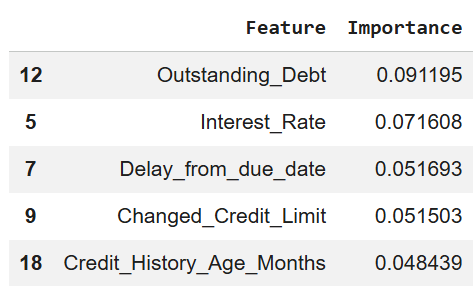

Berdasarkan nilai feature importance dari model Random Forest, terlihat bahwa:
1. Outstanding_Debt (0,091) -> Paling berpengaruh karena menunjukkan total utang nasabah. Semakin besar utang, semakin besar risiko kredit, sehingga fitur ini sering dipakai model saat membuat keputusan.
2. Interest_Rate (0,072) -> Mencerminkan tingkat risiko pinjaman. Bunga yang tinggi biasanya berkaitan dengan profil kredit yang lebih berisiko.
3. Delay_from_due_date (0,052) -> Menggambarkan kebiasaan keterlambatan pembayaran. Nasabah yang sering telat bayar cenderung memiliki credit score yang lebih rendah.
4. Changed_Credit_Limit (0,052) -> Menunjukkan perubahan limit kredit, yang bisa menjadi indikator kestabilan atau perubahan kondisi finansial nasabah.
5. Credit_History_Age_Months (0,048) -> Menggambarkan lama riwayat kredit. Riwayat kredit yang lebih panjang memberi lebih banyak informasi bagi model untuk menilai kelayakan kredit.

Berdasarkan hasil feature importance, dapat disimpulkan bahwa model paling banyak mengandalkan informasi yang berkaitan dengan utang dan risiko kredit, terutama Outstanding_Debt dan Interest_Rate, dalam memprediksi credit score. Faktor perilaku pembayaran seperti Delay_from_due_date serta perubahan limit kredit juga berperan cukup besar, sementara lamanya riwayat kredit berfungsi sebagai pendukung dalam pengambilan keputusan model. Secara keseluruhan, hasil ini menunjukkan bahwa kondisi keuangan dan kebiasaan pembayaran nasabah menjadi faktor utama dalam menentukan kualitas credit score.